# 02 - Variable Deep-Dive EDA

This notebook profiles each variable with practical diagnostics:
- type, missingness, uniqueness
- distribution stats
- outlier ratios for numeric features
- top levels for categorical features

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [19]:
df_load = pd.read_excel('../../data/raw/cars.xlsx')

df_load.columns()

print('shape:', df_load.shape)
df_load.head(2)

shape: (78025, 19)


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.69636,0.113985,0.154215,10K or less
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.00000,1.000000,0.000000,10K or less


In [16]:
df = df_load.copy()
del df_load["Opportunity Number"]

## Variable inventory

In [17]:
rows = []
for c in df.columns:
    s = df[c]
    # convert list/array-valued columns to string so nunique/sample_values work
    if s.dtype == 'object' and len(s) > 0 and isinstance(s.iloc[0], (list, np.ndarray)):
        s = s.apply(str)
    row = {
        'variable': c,
        'dtype': str(df[c].dtype),
        'missing_pct': round(df[c].isna().mean() * 100, 2),
        'n_unique': int(s.nunique(dropna=True)),
        'sample_values': ', '.join(map(str, s.dropna().head(3).tolist()))
    }
    if pd.api.types.is_numeric_dtype(s):
        # cast bools to float so numpy arithmetic works (bool subtract is unsupported)
        if pd.api.types.is_bool_dtype(s):
            s = s.astype(float)
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        row.update({
            'mean': float(s.mean()),
            'std': float(s.std()),
            'p01': float(s.quantile(0.01)),
            'p50': float(s.quantile(0.50)),
            'p99': float(s.quantile(0.99)),
            'outlier_pct_iqr': round((((s < low) | (s > high)).mean() * 100), 2)
        })
    rows.append(row)

var_profile = pd.DataFrame(rows).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
var_profile

,variable,dtype,missing_pct,n_unique,sample_values,mean,std,p01,p50,p99,outlier_pct_iqr
14,Competitor Type,str,11.86,2,"Unknown, Unknown, Unknown",NaN,NaN,NaN,NaN,NaN,NaN
0,Opportunity Number,int64,0.00,77829,"1641984, 1658010, 1674737",7.653429e+06,1.054848e+06,5650940.8,7545569.000,9952303.76,0.18
16,Ratio Days Validated To Total Days,float64,0.00,13992,"0.113985, 1.0, 0.0",4.883139e-01,4.480771e-01,0.0,0.448,1.00,0.00
17,Ratio Days Qualified To Total Days,float64,0.00,10106,"0.154215, 0.0, 0.0",1.850478e-01,3.402831e-01,0.0,0.000,1.00,19.16
10,Opportunity Amount USD,int64,0.00,9879,"0, 0, 7750",9.163726e+04,1.331610e+05,0.0,49000.000,700000.00,9.32
15,Ratio Days Identified To Total Days,float64,0.00,9786,"0.69636, 0.0, 1.0",2.030631e-01,3.649845e-01,0.0,0.000,1.00,19.20
8,Total Days Identified Through Closing,int64,0.00,156,"104, 163, 82",1.672836e+01,1.672959e+01,0.0,12.000,74.00,3.47
9,Total Days Identified Through Qualified,int64,0.00,156,"101, 163, 82",1.631435e+01,1.656260e+01,0.0,12.000,73.00,3.29
5,Elapsed Days In Sales Stage,int64,0.00,138,"76, 63, 24",4.359535e+01,2.658560e+01,0.0,43.000,91.00,0.01
7,Sales Stage Change Count,int64,0.00,22,"13, 2, 7",2.955732e+00,1.497242e+00,1.0,3.000,8.00,11.97


## Numeric distributions

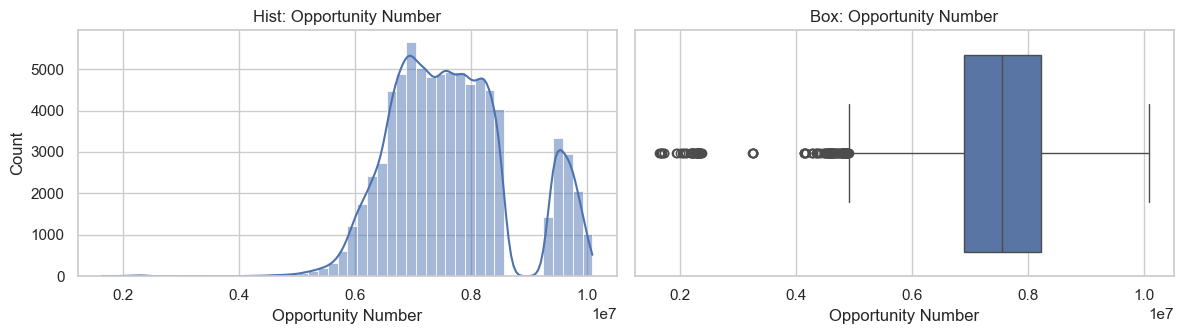

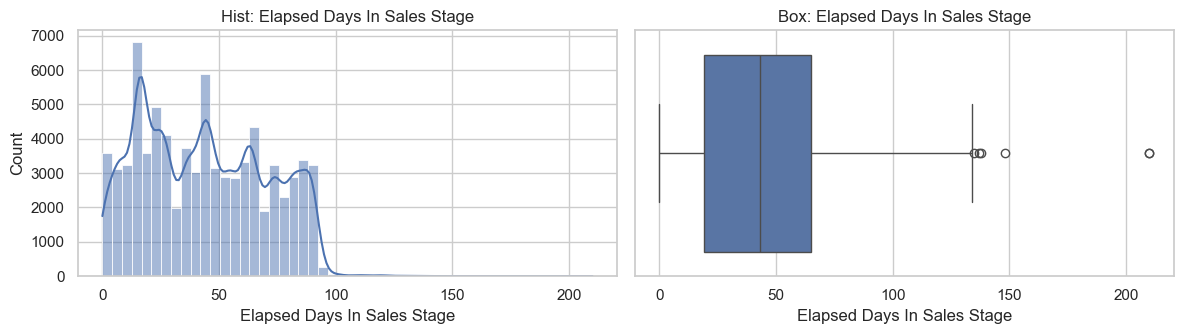

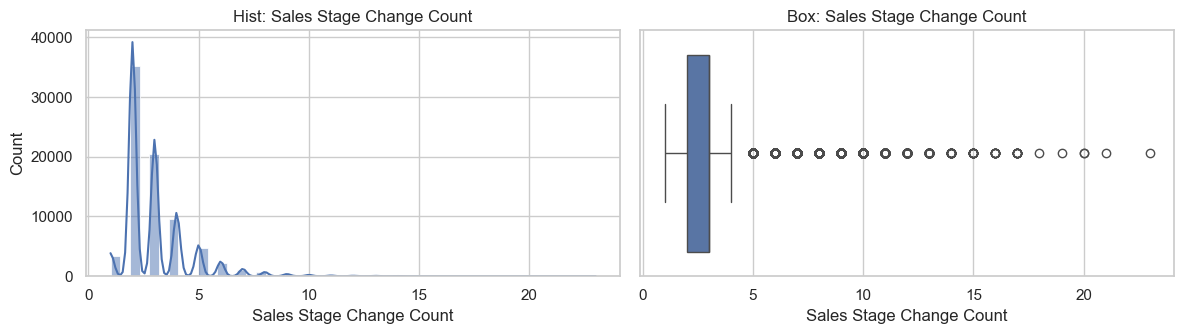

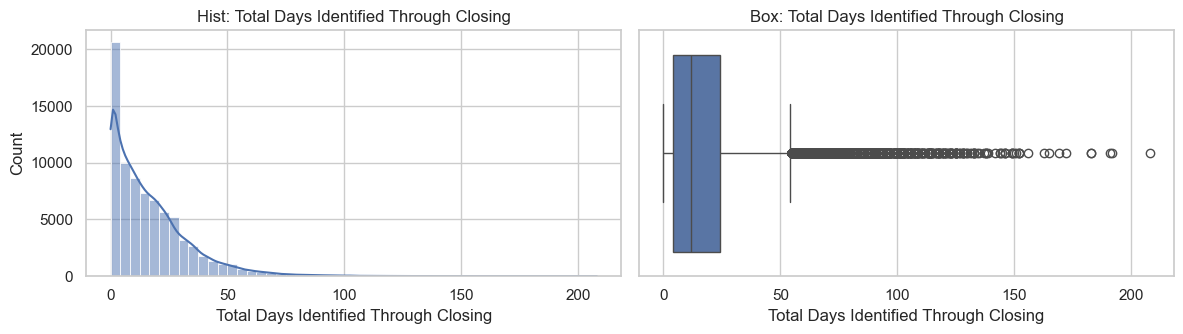

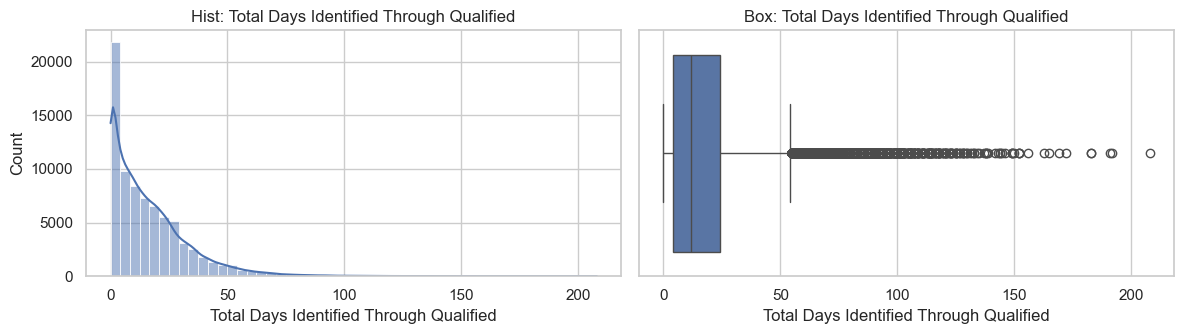

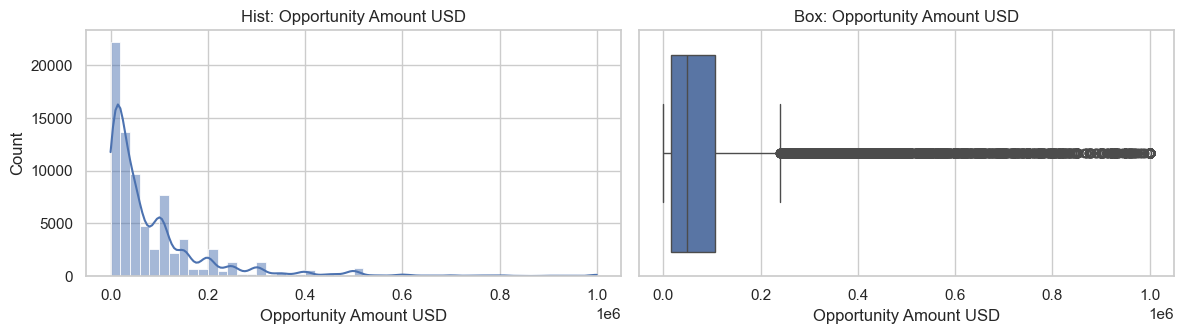

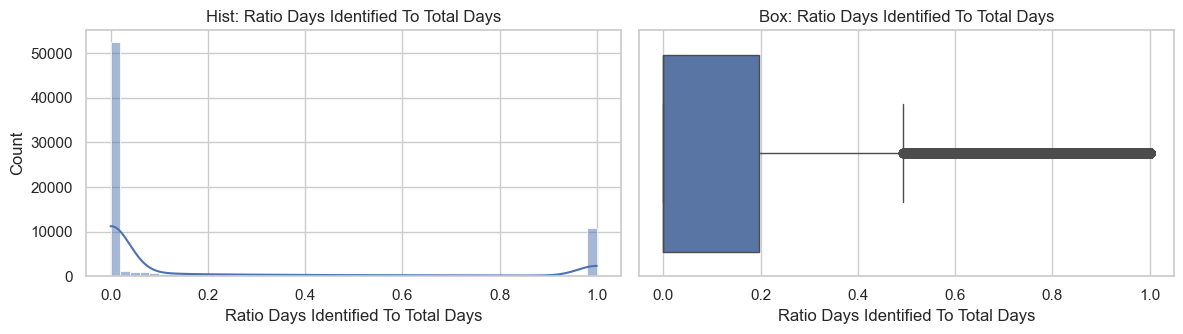

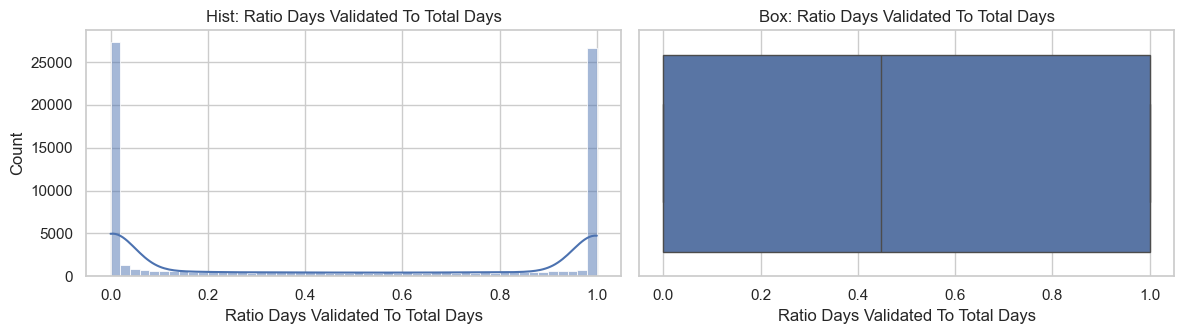

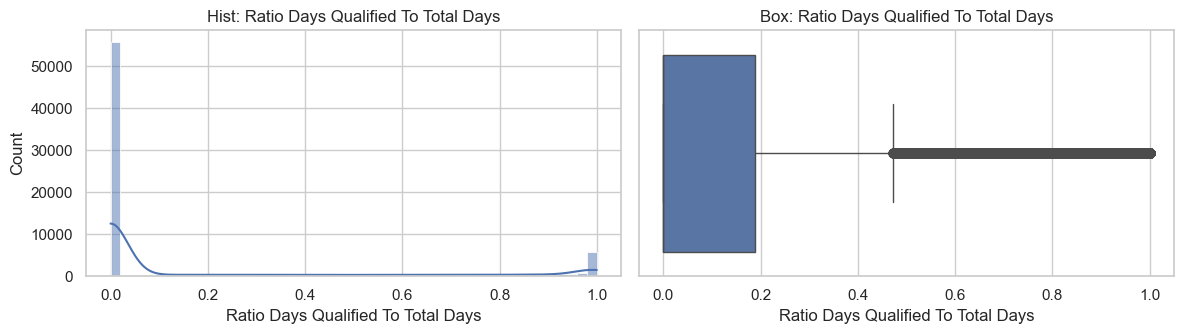

In [18]:
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'Hist: {col}')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Box: {col}')

    plt.tight_layout()
    plt.show()

## Categorical distributions

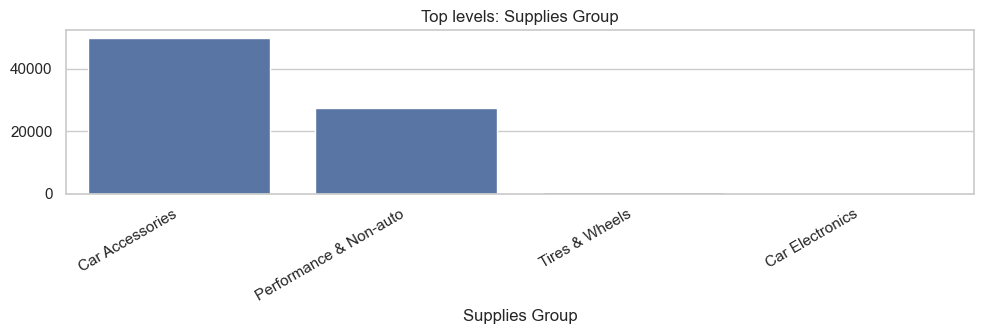

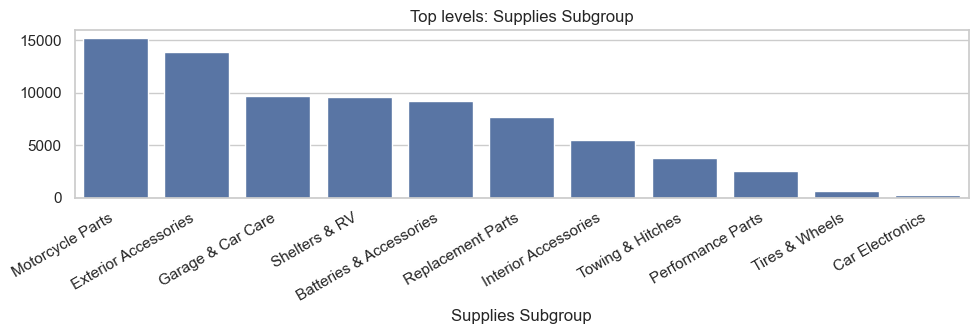

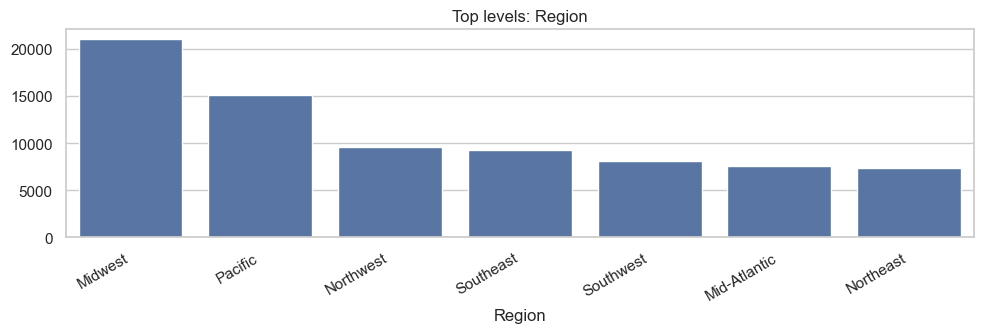

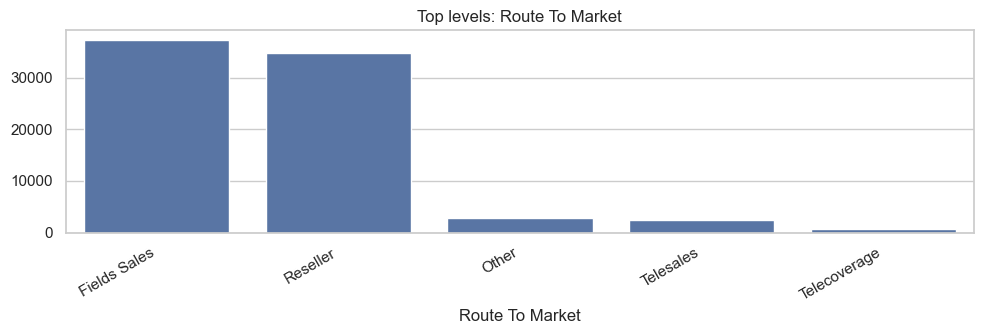

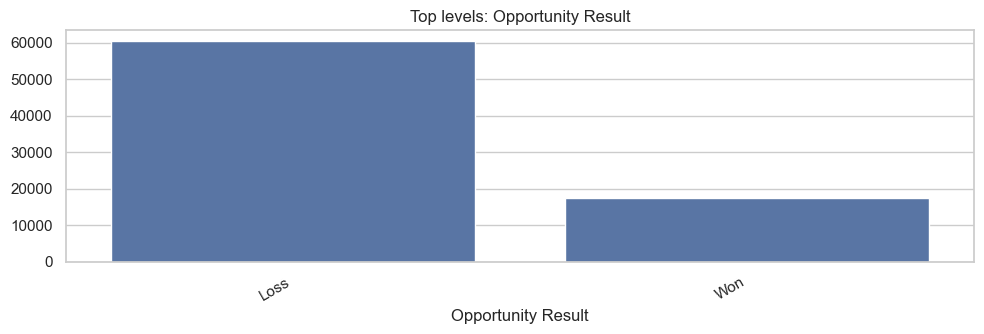

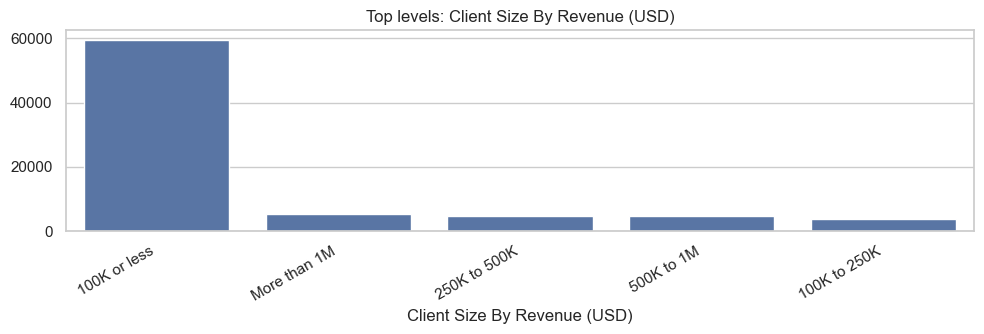

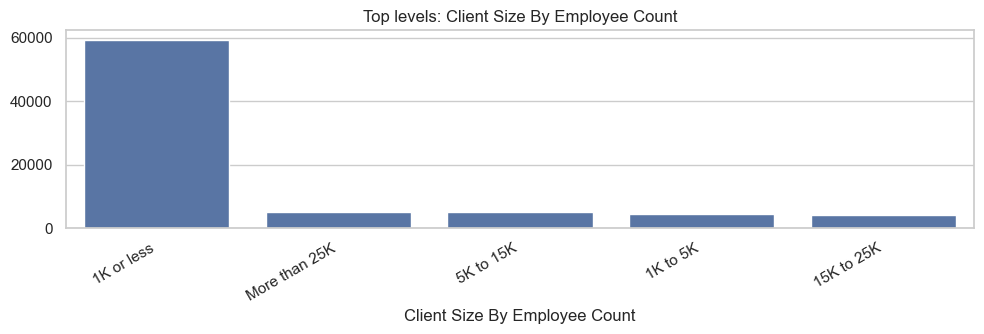

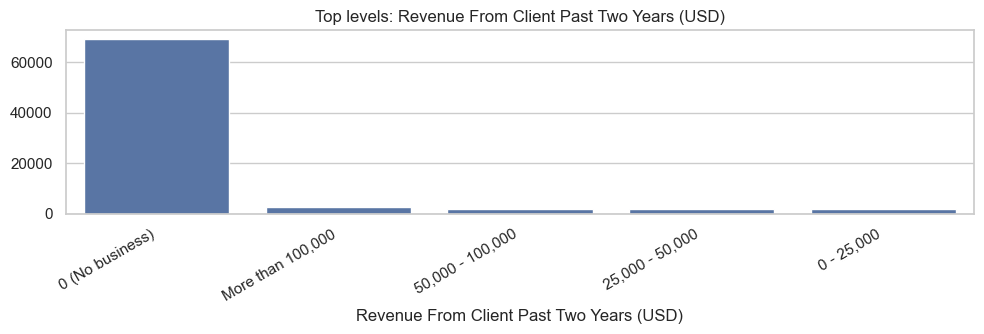

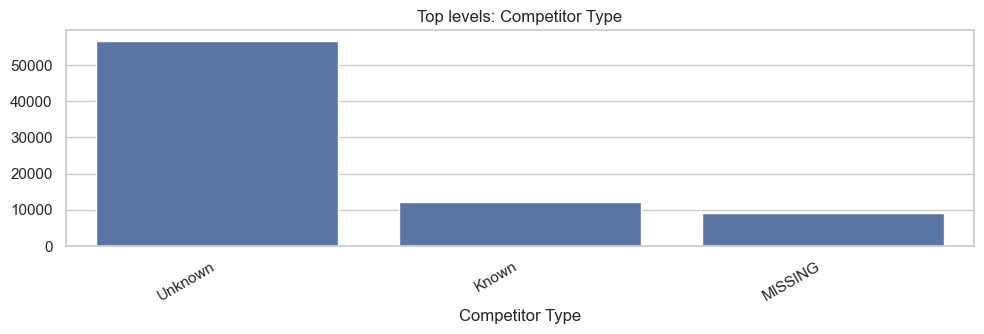

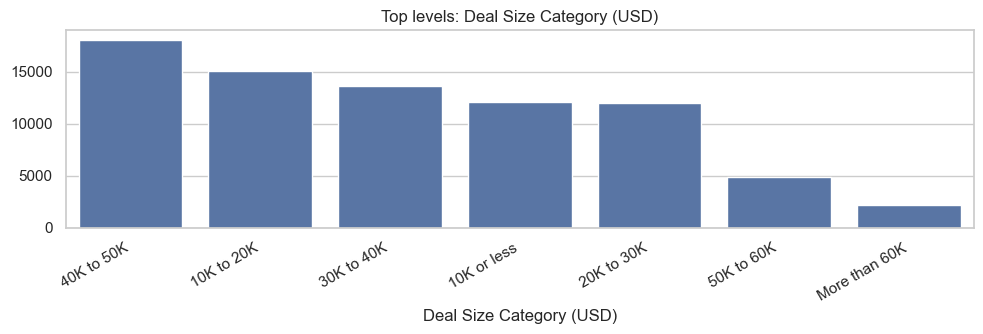

In [6]:
cat_cols = df.select_dtypes(exclude=['number', 'bool']).columns.tolist()
# skip list/array-valued columns (e.g. problem_tags) – unhashable for value_counts
cat_cols = [c for c in cat_cols if not (df[c].dtype == 'object' and len(df[c].dropna()) > 0 and isinstance(df[c].dropna().iloc[0], (list, np.ndarray)))]
for col in cat_cols:
    vc = df[col].fillna('MISSING').value_counts().head(12)
    plt.figure(figsize=(10, 3.5))
    sns.barplot(x=vc.index.astype(str), y=vc.values)
    plt.title(f'Top levels: {col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Target-focused quick view

In [7]:
print('Win/Loss distribution (%)')
print((df['Opportunity Result'].value_counts(normalize=True) * 100).round(2))

print('\nDeal Size Category distribution (%)')
print((df['Deal Size Category (USD)'].value_counts(normalize=True) * 100).round(2))

print('\nAmount summary')
print(df['Opportunity Amount USD'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

Win/Loss distribution (%)
Opportunity Result
Loss    77.41
Won     22.59
Name: proportion, dtype: float64

Deal Size Category distribution (%)
Deal Size Category (USD)
40K to 50K       23.16
10K to 20K       19.38
30K to 40K       17.47
10K or less      15.50
20K to 30K       15.34
50K to 60K        6.32
More than 60K     2.82
Name: proportion, dtype: float64

Amount summary
count      78025.000000
mean       91637.260750
std       133161.029156
min            0.000000
1%             0.000000
5%          1192.800000
50%        49000.000000
95%       350000.000000
99%       700000.000000
max      1000000.000000
Name: Opportunity Amount USD, dtype: float64
